In [112]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
from openai import OpenAI
from sklearn.metrics import f1_score,roc_auc_score
import random
import json
import matplotlib.pyplot as plt
import base64
from PIL import Image
import io

Nitrogen dioxide, Wind speed, Wind direction (in degrees), Temperature, Humidity, Pressure, Solar irradiance, Intensity, Occupancy time, Load, Average traffic speed, Wind direction (after converting to categorical data (north, northeast, east, southeast, south, southwest, west, northwest)

In [113]:
data = pd.read_csv('Mad_Station_2019.csv')

In [114]:
data = data.drop(columns=['windDir_Categ_east', 'windDir_Categ_north', 'windDir_Categ_northeast',
       'windDir_Categ_northwest', 'windDir_Categ_south',
       'windDir_Categ_southeast', 'windDir_Categ_southwest',
       'windDir_Categ_west'])

In [115]:
data.columns = ['NO2', 'windSpeed', 'windDir', 'Temp', 'Humidity', 'Pressure',
       'SolarRad', 'intensity', 'Occupancy', 'Load', 'TrafficSpeed']

In [116]:
data = data.drop(columns=['TrafficSpeed'])

In [117]:
data = data.drop(columns=['windDir', 'Pressure'])

In [118]:
data = data.drop(columns=['Load'])

In [119]:
data.shape

(104256, 7)

In [120]:
data_df = data.iloc[:4344, :]

In [121]:
data_df.iloc[-5:, :]

,NO2,windSpeed,Temp,Humidity,SolarRad,intensity,Occupancy
4339,102.0,0.52,9.5,39.0,429.0,550.79,12.74
4340,47.0,0.84,9.3,33.0,466.0,387.75,2.75
4341,58.0,0.37,10.3,28.0,469.0,781.52,11.67
4342,64.0,0.52,9.5,39.0,429.0,189.33,3.22
4343,24.0,0.52,9.0,36.0,429.0,0.00,0.00


In [122]:
iter_start_time = pd.to_datetime('2019-01-01')
# 最后一个 t 必须保证后面有6小时数据
iter_end_time = pd.to_datetime('2019-07-01')
iterator_range = pd.date_range(start=iter_start_time, end=iter_end_time, freq='1H')

/var/folders/1m/p12njtr95cx_k2hpdn2ytcx40000gn/T/ipykernel_39670/3390939442.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  iterator_range = pd.date_range(start=iter_start_time, end=iter_end_time, freq='1H')


In [123]:
iterator_range

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2019-06-30 15:00:00', '2019-06-30 16:00:00',
               '2019-06-30 17:00:00', '2019-06-30 18:00:00',
               '2019-06-30 19:00:00', '2019-06-30 20:00:00',
               '2019-06-30 21:00:00', '2019-06-30 22:00:00',
               '2019-06-30 23:00:00', '2019-07-01 00:00:00'],
              dtype='datetime64[ns]', length=4345, freq='h')

In [126]:
# --- 构造实验数据集 (滑动窗口生成样本和标签) ---
print("\n--- Constructing traffic dataset ---")

window_size = 12
step_size = 6
absolute_threshold = 2

samples = []
labels = []
futures = []

# data_df 包含了我们需要的所有列
# 确保 Occupancy 列存在
if 'Occupancy' not in data_df.columns:
    raise ValueError("Column 'Occupancy' not found in data_df")

num_rows = len(data_df)

# 遍历数据
# 我们需要 i + 12 (历史) + 1 (未来) <= len(data_df)
# 也就是 future_idx (i + 12) 必须是有效的索引，最大为 num_rows - 1
for i in range(0, num_rows - window_size, step_size):

    # 1. 获取历史12个时刻的数据
    # shape: (12, num_features)
    hist_window = data_df.iloc[i : i + window_size]

    # 2. 获取未来1个时刻的 Occupancy
    future_idx = i + window_size

    # 再次检查索引是否越界
    if future_idx >= num_rows:
        break

    future_occupancy = data_df.iloc[future_idx]['Occupancy']
    futures.append(future_occupancy)

    # 3. 获取历史窗口中最后一个时刻的 Occupancy
    last_occupancy = hist_window.iloc[-1]['Occupancy']

    # 4. 确定 Label
    if future_occupancy < last_occupancy - absolute_threshold:
        label = 0
    elif future_occupancy > last_occupancy + absolute_threshold:
        label = 2
    else:
        label = 1

    samples.append(hist_window.values)
    labels.append(label)

# 转换为 numpy 数组
samples_array = np.array(samples)
labels_array = np.array(labels)
futures_array = np.array(futures)

print(f"Generated {len(samples)} samples.")
print(f"Samples shape: {samples_array.shape}")
print(f"Labels shape: {labels_array.shape}")
print(f"Label distribution: {np.unique(labels_array, return_counts=True)}")

# 保存
with open('data.pkl', 'wb') as f:
    pkl.dump(samples_array, f)
with open('labels.pkl', 'wb') as f:
    pkl.dump(labels_array, f)
with open('futures.pkl', 'wb') as f:
    pkl.dump(futures_array, f)

print("Saved to data.pkl and labels.pkl")


--- Constructing traffic dataset ---
Generated 722 samples.
Samples shape: (722, 12, 7)
Labels shape: (722,)
Label distribution: (array([0, 1, 2]), array([108, 377, 237]))
Saved to data.pkl and labels.pkl


In [129]:
futures_array.shape

(722,)

In [130]:
data_df.columns

Index(['NO2', 'windSpeed', 'Temp', 'Humidity', 'SolarRad', 'intensity',
       'Occupancy'],
      dtype='object')

In [132]:
labels_array.shape

(722,)

In [73]:
images_dir = 'images'
if not os.path.exists(images_dir):
    os.makedirs(images_dir)

column_names = ['NO2', 'WindSpeed', 'Temp', 'Humidity', 'SolarRad', 'Itensity', 'Occupancy']

colors = ['red', 'green', 'blue', 'black', 'orange', 'purple', 'brown']
seq_len = 12  # 144
num_variables = len(column_names)


sum_ = 0

for i in range(samples_array.shape[0]):
    # print(i)
    sum_ += 1

    sample = samples_array[i]

    # Removed sharex=True to ensure all subplots show x-axis tick labels
    fig, axes = plt.subplots(nrows=num_variables, ncols=1, figsize=(10, 12))

    for j in range(num_variables):
        ax = axes[j]
        ax.plot(sample[:,j], color=colors[j], linewidth=2)
        ax.set_ylabel("Value", fontsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.legend([column_names[j]], fontsize=8)

        # # 为每个数据点添加数值标签
        # y_values = sample[:, j+1]
        # x_values = np.arange(len(y_values))
        # for x_pos, y_pos in zip(x_values, y_values):
        #     ax.text(x_pos, y_pos, f'{y_pos:.2f}', fontsize=6, ha='center', va='bottom', color='darkgreen')

        # Set x-axis properties for every subplot
        ax.set_xlabel("Time (h)", fontsize=10)

        tick_positions = np.arange(0, seq_len, 1)
        tick_positions = np.append(tick_positions, seq_len - 1)  # Ensure the last tick is at the end
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_positions + 1)

        # ax.set_xticks(np.arange(0, seq_len + 4, 4))
        ax.set_xlim(-1, seq_len)
        ax.tick_params(axis='x', labelsize=8, rotation=0)

        ax.grid(True, linestyle='--', alpha=0.5)


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # 调整子图之间的垂直间距，值越小，间距越小
    fig.subplots_adjust(hspace=0.55)

    plt.savefig(os.path.join(images_dir, f'{i}.png'))
    plt.close(fig)

print(f"Generated and saved images in {images_dir}")
print(sum_)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

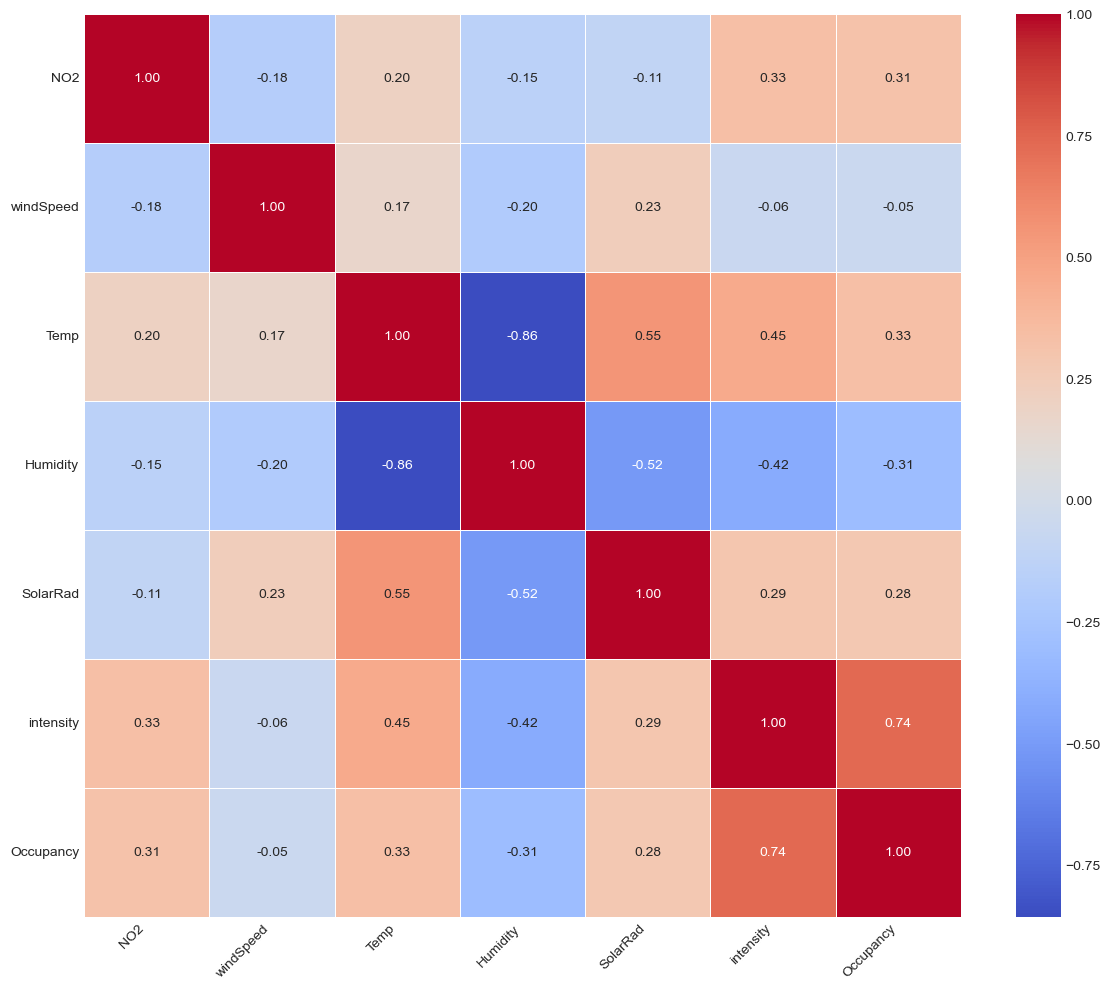

In [90]:

# --- 相关性分析与热力图绘制 ---
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

# 1. 将numpy数据转换为pandas DataFrame以便于分析
# 我们使用之前确定的列名，并跳过第一列（因为它不是金融数据）
column_names = ['NO2', 'windSpeed', 'Temp', 'Humidity', 'SolarRad', 'intensity',
       'Occupancy']

data_array = data.iloc[:4344,:].values
n_features = data_array.shape[1]
correlation_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        x = data_array[:, i]
        y = data_array[:, j]
        corr_coeff, _ = pearsonr(x, y)
        correlation_matrix[i, j] = corr_coeff

# 2c. 将numpy相关性矩阵转换为带标签的DataFrame，方便绘图
corr_df = pd.DataFrame(correlation_matrix, index=column_names, columns=column_names)

# 2d. 创建一个遮罩 (mask) 来隐藏上三角部分（不包括对角线）
# mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

# 3. 绘制热力图
plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
# plt.title('Lower Triangle Correlation Matrix of Financial Instruments', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('traffic_CM.pdf')
plt.show()

In [78]:
samples_array.shape

(722, 12, 7)

In [2]:
labels_array.shape

NameError: name 'labels_array' is not defined

In [ ]:
import huggingface_hub

# 2. 登录 (使用环境变量中的 Token)
huggingface_hub.login(token=os.getenv("HF_TOKEN"))

import numpy as np
import warnings

from tabpfn import TabPFNClassifier
from tabpfn_extensions.embedding import TabPFNEmbedding
from sklearn.model_selection import train_test_split
import pickle as pkl

with open('data.pkl', 'rb') as f:
    data = pkl.load(f)
with open('labels.pkl', 'rb') as f:
    labels = pkl.load(f)


# ==========================================
# 0. 权限认证 (必须先执行这一步)
# ==========================================
# 请取消注释并填入你的 Token，或者确保已经在终端运行过 `hf auth login`
# huggingface_hub.login(token="hf_xxxxxxxxxxxxxxxxxxxxxxxx")

warnings.filterwarnings("ignore")

def get_dual_embeddings_v2(X_train, y_train, X_test, device='cpu'):
    """
    针对 TabPFN-Extensions 新版 API (get_embeddings) 的修正函数
    """
    # 1. 维度处理 (Flatten)
    N_train, T, V = X_train.shape
    N_test = X_test.shape[0]

    print(f"输入维度: 训练集={X_train.shape}, 测试集={X_test.shape}")

    X_train_flat = X_train.reshape(N_train, T * V)
    X_test_flat = X_test.reshape(N_test, T * V)

    # 2. 初始化 (注意：这里使用 n_fold 控制交叉验证逻辑)
    # n_fold=5: 获取训练集 embedding 时会使用 5折交叉验证（防止泄漏）
    # n_fold=0: 获取测试集 embedding 时会使用全量训练集作为 Context
    # TabPFNEmbedding 这个类现在主要作为配置容器
    classifier = TabPFNClassifier(device=device)
    embedder = TabPFNEmbedding(classifier, n_fold=5)

    # 3. Fit (加载数据到提取器)
    print("正在初始化提取器 (Fit)...")
    embedder.fit(X_train_flat, y_train)

    # 4. 获取 Embedding (使用新版 API: get_embeddings)
    # 新版 API 要求显式指定 data_source

    print("正在生成训练集 Embedding (CV模式)...")
    # data_source='train' 会触发 n_fold 交叉验证逻辑
    train_embs = embedder.get_embeddings(
        X_train_flat, y_train, X_test_flat, data_source='train'
    )

    print("正在生成测试集 Embedding (Inference模式)...")
    # data_source='test' 会使用全量 X_train, y_train 作为 Context 预测 X_test
    test_embs = embedder.get_embeddings(
        X_train_flat, y_train, X_test_flat, data_source='test'
    )

    return train_embs, test_embs

# ==========================================
# 运行测试
# ==========================================
if __name__ == "__main__":
    # 模拟数据
    N_total = 100
    T, V = 12, 7
    X_raw = np.random.randn(N_total, T, V)
    y_raw = np.random.randint(0, 2, N_total)

    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

    try:
        train_e, test_e = get_dual_embeddings_v2(X_train, y_train, X_test, device='cpu')
        print("\n=== 成功 ===")
        print(f"Train Embeddings: {train_e.shape}")
        print(f"Test Embeddings:  {test_e.shape}")
    except RuntimeError as e:
        if "Authentication" in str(e) or "gated" in str(e):
            print("\n!!! 错误: 请先完成 HuggingFace 认证 !!!")
            print("1. 去 https://huggingface.co/Prior-Labs/tabpfn_2_5 点击 Agree")
            print("2. 在代码中使用 huggingface_hub.login(token='...')")
        else:
            raise e
train_e = train_e[-1]
test_e = test_e[-1]

In [43]:
# --- 读取和检查 vector_db.pkl ---
import pickle

# 假设此 notebook 从项目根目录运行, 调整相对路径
vector_db_path = '../../vector_db/traffic/vector_db.pkl'

try:
    with open(vector_db_path, 'rb') as f:
        vector_db_data = pickle.load(f)

    print("--- Vector DB Data Loaded Successfully ---")

    # 打印数据库中包含的键
    print("Keys in the vector database:", list(vector_db_data.keys()))

    # 打印元数据的前几行
    print("\nMetadata Head:")
    print(vector_db_data['metadata'].head())

    vector_db_data['metadata'].to_csv('../../vector_db/LargeAQ/vector_db.csv')

    # 打印向量的形状
    print("\nShape of coarse_embeddings:", vector_db_data['coarse_embeddings'].shape)
    print("Shape of fine_embeddings:", vector_db_data['fine_embeddings'].shape)
    print("Length of chunk_to_doc_id_map:", len(vector_db_data['chunk_to_doc_id_map']))
    print("Number of chunks in all_chunk_texts:", len(vector_db_data['all_chunk_texts']))

except FileNotFoundError:
    print(f"Error: Vector database file not found at '{vector_db_path}'.")
    print("Please run 'build_vector_db.py' first to create the database.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

--- Vector DB Data Loaded Successfully ---
Keys in the vector database: ['metadata', 'coarse_embeddings', 'fine_embeddings', 'chunk_to_doc_id_map', 'all_chunk_texts']

Metadata Head:
   id  true_label                                     reasoning_path
0   0           1  - Occupancy declined 6 → 3 → 2 over the last t...
1   1           2  - Occupancy drops to an extreme trough at the ...
2   2           2  - Occupancy shows an oscillatory pattern with ...
3   3           2  - Occupancy shows a steady upswing over the la...
4   4           2  - Intensity surges from a trough at h9 to sust...

Shape of coarse_embeddings: (577, 3072)
Shape of fine_embeddings: (4337, 3072)
Length of chunk_to_doc_id_map: 4337
Number of chunks in all_chunk_texts: 4337


In [44]:
vector_db_data['metadata'].iloc[[9],:]

,id,true_label,reasoning_path
9,9,2,- Occupancy has stayed near a trough for sever...


In [2]:
import numpy as np
import pickle as pkl

data_df = pkl.load(open('data.pkl', 'rb'))

In [3]:
data_df.shape

(722, 12, 7)

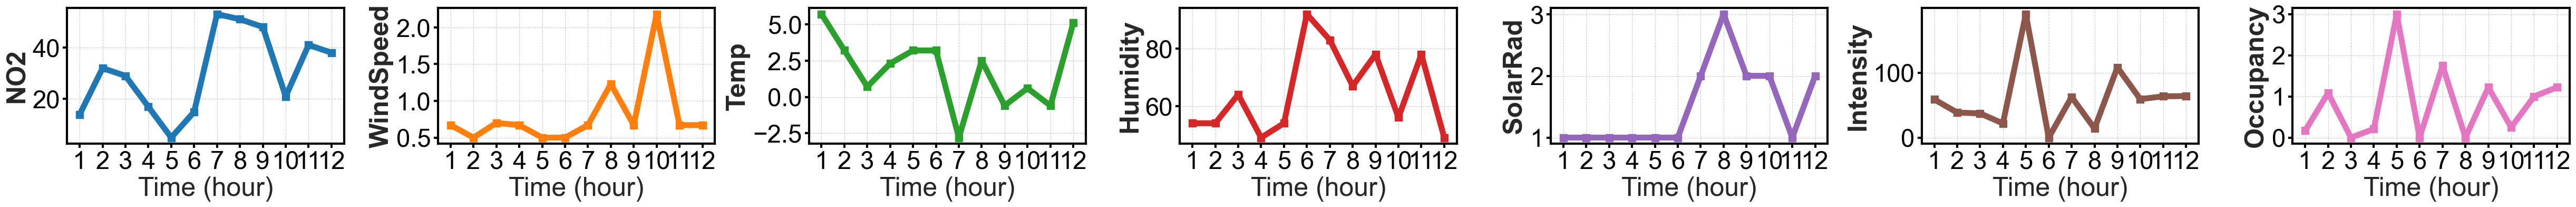

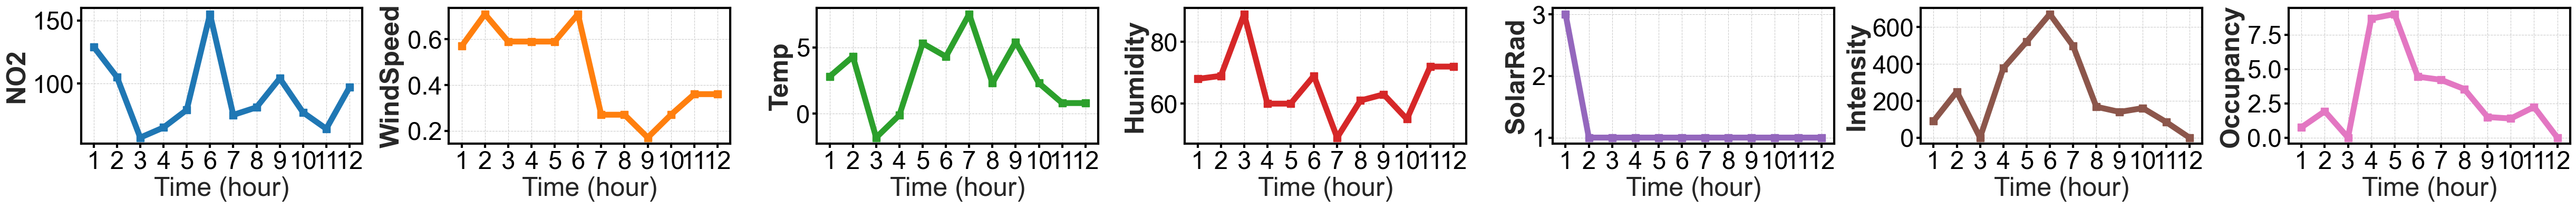

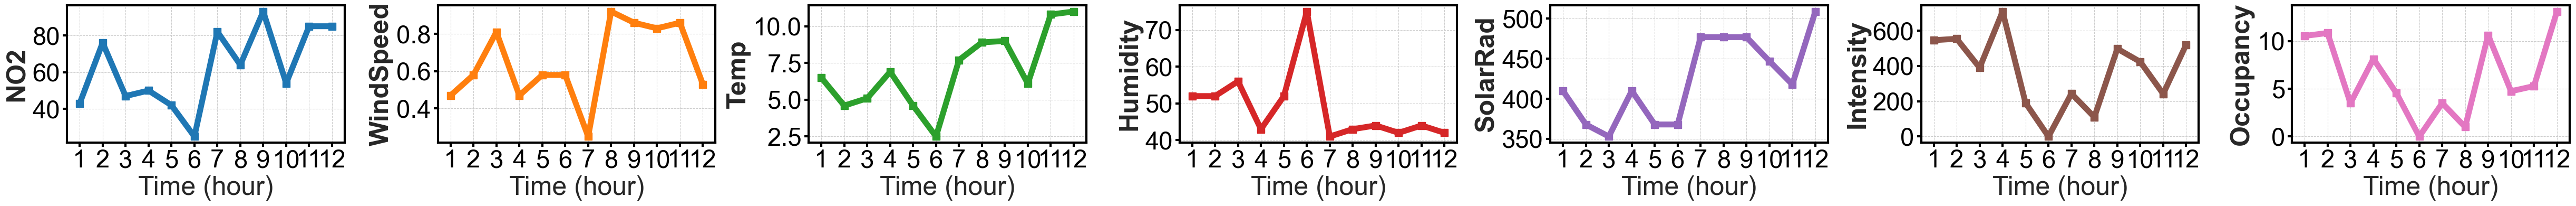

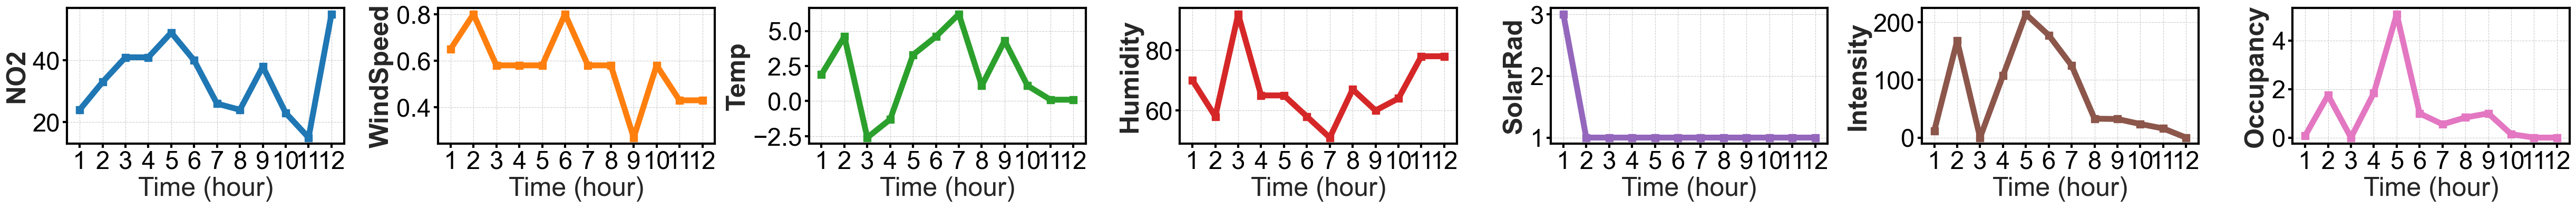

In [5]:
import matplotlib.pyplot as plt
import numpy as np

idxs = [211, 385, 143, 305]


# 定义纵坐标标签
y_labels = ['NO2', 'WindSpeed', 'Temp', 'Humidity', 'SolarRad', 'Intensity', 'Occupancy']
hours = np.arange(1, 13)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# 2. 设置绘图参数
# 使用简洁风格，但稍后我们会手动覆盖边框设置
# plt.style.use('seaborn-v0_8-whitegrid')
# fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(7, 14), sharex=True)

# 3. 循环绘制
for idx in idxs:
    data = data_df[idx].T
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(49, 4), sharex=True)

    # 3. 循环绘制
    for i, ax in enumerate(axes):
        # 绘制数据
        ax.plot(hours, data[i], marker='s', linestyle='-', color=colors[i],
                linewidth=8, markersize=10, label=y_labels[i])

        # 设置网格
        ax.grid(True, linestyle='--', alpha=1)

        # --- 修改点 1: 设置黑色边框 ---
        for spine in ax.spines.values():
            spine.set_edgecolor('black')  # 边框颜色
            spine.set_linewidth(3.0)      # 边框粗细

        # --- 修改点 2: 设置刻度小短线 (Tick Marks) ---
        ax.tick_params(
            axis='both',        # x轴和y轴同时设置
            which='major',      # 主刻度
            direction='out',     # 刻度线朝内 (in/out/inout)
            bottom=True,        # 显示底部刻度线
            left=True,          # 显示左侧刻度线
            right=False,         # 显示右侧刻度线 (可选，形成封闭框效果)
            top=False,           # 显示顶部刻度线 (可选，形成封闭框效果)
            length=6,           # 刻度线长度
            width=3,            # 刻度线宽度
            colors='black',     # 刻度线颜色
            labelsize=34         # 刻度文字大小
        )
        ax.locator_params(axis='y', nbins=4)

        # 设置图例
        # ax.legend(fontsize=24, framealpha=0.5, edgecolor='gray' ,labelspacing=0.2, loc='center right', frameon=True)

        ax.set_ylabel(y_labels[i], fontsize=36, fontweight='bold')

        ax.set_xlabel('Time (hour)', fontsize=36)
        ax.set_xticks(hours)
        ax.set_xticklabels(hours, fontsize=34)

    # # 4. 设置公共横坐标
    # axes[-1].set_xlabel('Time (hour)', fontsize=26)
    # axes[-1].set_xticks(hours)
    # axes[-1].set_xticklabels(hours, fontsize=24)

    # 紧凑布局
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.15)

    plt.savefig('traffic_image_{}.png'.format(idx), dpi=300)
    # plt.show()

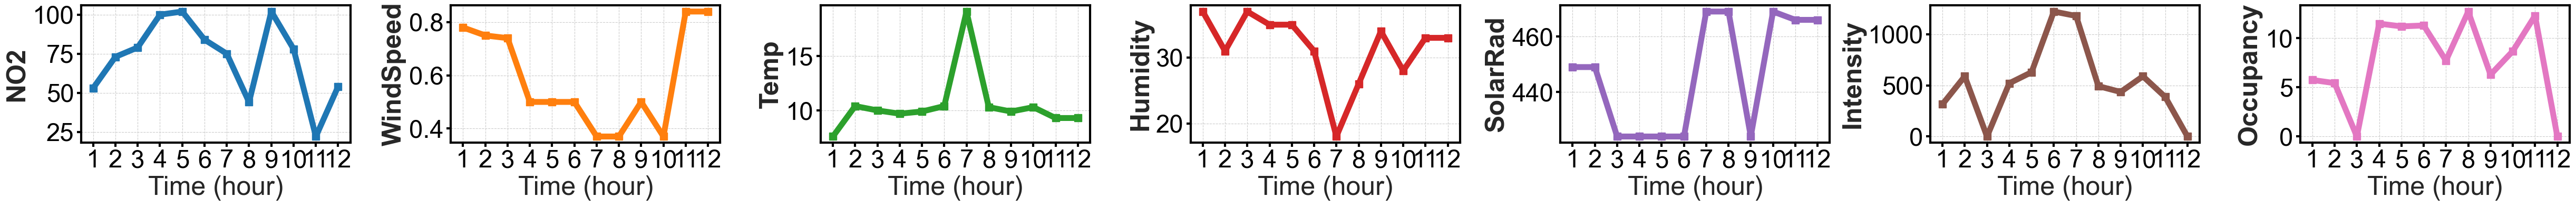

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备数据
data = np.array([
    [5.30e+01, 7.30e+01, 7.90e+01, 1.00e+02, 1.02e+02, 8.40e+01, 7.50e+01, 4.40e+01, 1.02e+02, 7.80e+01, 2.20e+01, 5.40e+01],
    [7.80e-01, 7.50e-01, 7.40e-01, 5.00e-01, 5.00e-01, 5.00e-01, 3.70e-01, 3.70e-01, 5.00e-01, 3.70e-01, 8.40e-01, 8.40e-01],
    [7.60e+00, 1.04e+01, 1.00e+01, 9.70e+00, 9.90e+00, 1.04e+01, 1.91e+01, 1.03e+01, 9.90e+00, 1.03e+01, 9.30e+00, 9.30e+00],
    [3.70e+01, 3.10e+01, 3.70e+01, 3.50e+01, 3.50e+01, 3.10e+01, 1.80e+01, 2.60e+01, 3.40e+01, 2.80e+01, 3.30e+01, 3.30e+01],
    [4.49e+02, 4.49e+02, 4.24e+02, 4.24e+02, 4.24e+02, 4.24e+02, 4.69e+02, 4.69e+02, 4.24e+02, 4.69e+02, 4.66e+02, 4.66e+02],
    [3.1550e+02, 5.8829e+02, 0.00e+00, 5.2039e+02, 6.2850e+02, 1.22174e+03, 1.17855e+03, 4.9250e+02, 4.3545e+02, 5.8861e+02, 3.8693e+02, 0.00e+00],
    [5.75e+00, 5.43e+00, 0.00e+00, 1.148e+01, 1.12e+01, 1.129e+01, 7.72e+00, 1.271e+01, 6.29e+00, 8.68e+00, 1.229e+01, 0.00e+00]
])

# 定义纵坐标标签
y_labels = ['NO2', 'WindSpeed', 'Temp', 'Humidity', 'SolarRad', 'Intensity', 'Occupancy']
hours = np.arange(1, 13)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# 2. 设置绘图参数
# 使用简洁风格，但稍后我们会手动覆盖边框设置
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(49, 4), sharex=True)

# 3. 循环绘制
for i, ax in enumerate(axes):
    # 绘制数据
    ax.plot(hours, data[i], marker='s', linestyle='-', color=colors[i],
            linewidth=8, markersize=10, label=y_labels[i])

    # 设置网格
    ax.grid(True, linestyle='--', alpha=1)

    # --- 修改点 1: 设置黑色边框 ---
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # 边框颜色
        spine.set_linewidth(3.0)      # 边框粗细

    # --- 修改点 2: 设置刻度小短线 (Tick Marks) ---
    ax.tick_params(
        axis='both',        # x轴和y轴同时设置
        which='major',      # 主刻度
        direction='out',     # 刻度线朝内 (in/out/inout)
        bottom=True,        # 显示底部刻度线
        left=True,          # 显示左侧刻度线
        right=False,         # 显示右侧刻度线 (可选，形成封闭框效果)
        top=False,           # 显示顶部刻度线 (可选，形成封闭框效果)
        length=6,           # 刻度线长度
        width=3,            # 刻度线宽度
        colors='black',     # 刻度线颜色
        labelsize=34         # 刻度文字大小
    )
    ax.locator_params(axis='y', nbins=4)

    # 设置图例
    # ax.legend(fontsize=24, framealpha=0.5, edgecolor='gray' ,labelspacing=0.2, loc='center right', frameon=True)

    ax.set_ylabel(y_labels[i], fontsize=36, fontweight='bold')

    ax.set_xlabel('Time (hour)', fontsize=36)
    ax.set_xticks(hours)
    ax.set_xticklabels(hours, fontsize=34)

# # 4. 设置公共横坐标
# axes[-1].set_xlabel('Time (hour)', fontsize=26)
# axes[-1].set_xticks(hours)
# axes[-1].set_xticklabels(hours, fontsize=24)

# 紧凑布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.15)

plt.savefig('traffic_image.png', dpi=300)
plt.show()